In [205]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lbquctrung/worksite-safety-monitoring-dataset/Worksite-Safety-Monitoring-Dataset/valid/unsafe/45.jpg
/kaggle/input/datasets/lbquctrung/worksite-safety-monitoring-dataset/Worksite-Safety-Monitoring-Dataset/valid/unsafe/56.jpg
/kaggle/input/datasets/lbquctrung/worksite-safety-monitoring-dataset/Worksite-Safety-Monitoring-Dataset/valid/unsafe/89.jpg
/kaggle/input/datasets/lbquctrung/worksite-safety-monitoring-dataset/Worksite-Safety-Monitoring-Dataset/valid/unsafe/20.jpg
/kaggle/input/datasets/lbquctrung/worksite-safety-monitoring-dataset/Worksite-Safety-Monitoring-Dataset/valid/unsafe/58.jpg
/kaggle/input/datasets/lbquctrung/worksite-safety-monitoring-dataset/Worksite-Safety-Monitoring-Dataset/valid/unsafe/6.jpg
/kaggle/input/datasets/lbquctrung/worksite-safety-monitoring-dataset/Worksite-Safety-Monitoring-Dataset/valid/unsafe/76.jpg
/kaggle/input/datasets/lbquctrung/worksite-safety-monitoring-dataset/Worksite-Safety-Monitoring-Dataset/valid/unsafe/71.jpg
/kaggle/i

In [206]:
# ==========================================
# Construction and Civil Monitoring
# Worksite Safety Monitoring Dataset
# PART 1 - Import Libraries & Load Dataset
# ==========================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import seaborn as sns

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [207]:
# Update this path according to your Kaggle dataset

train_dir = "/kaggle/input/datasets/lbquctrung/worksite-safety-monitoring-dataset/Worksite-Safety-Monitoring-Dataset/train"
valid_dir = "/kaggle/input/datasets/lbquctrung/worksite-safety-monitoring-dataset/Worksite-Safety-Monitoring-Dataset/valid"
test_dir = "/kaggle/input/datasets/lbquctrung/worksite-safety-monitoring-dataset/Worksite-Safety-Monitoring-Dataset/test"

In [208]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [209]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [210]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 1620 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


In [211]:
print(train_generator.class_indices)

{'safe': 0, 'unsafe': 1}


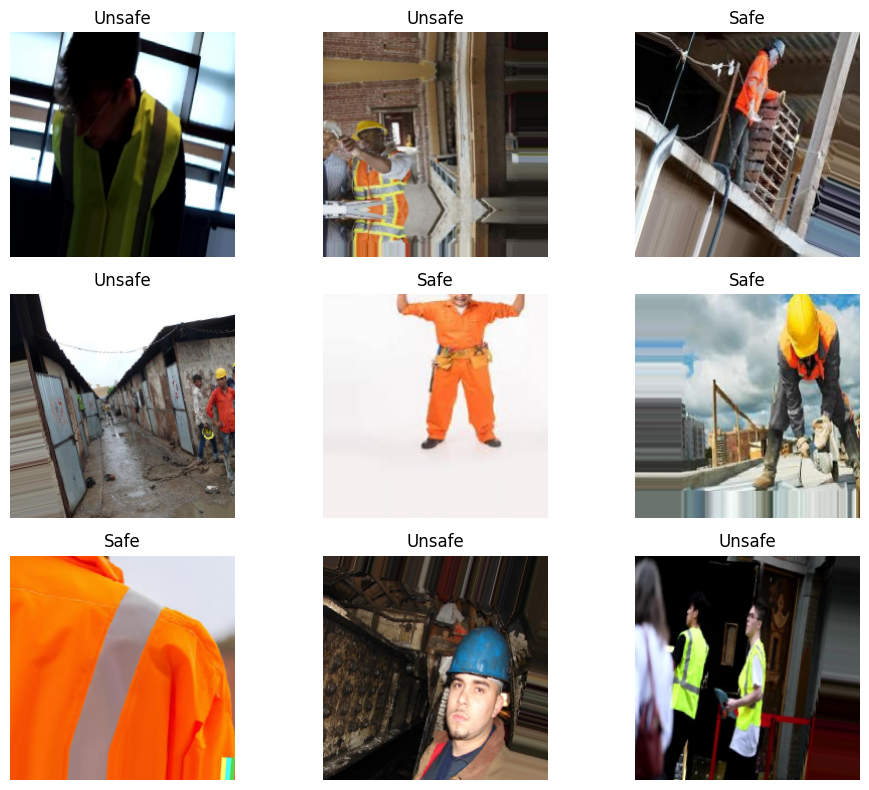

In [212]:
images, labels = next(train_generator)

plt.figure(figsize=(10, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title("Safe" if labels[i] == 0 else "Unsafe")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [213]:
# ==========================================
# PART 2 - Custom CNN Model
# ==========================================

custom_cnn = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')

])

custom_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,858,881 (37.61 MB)

 Trainable params: 9,858,881 (37.61 MB)

 Non-trainable params: 0 (0.00 B)

In [214]:
custom_cnn.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [215]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [216]:
history_cnn = custom_cnn.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 28s 452ms/step - accuracy: 0.4895 - loss: 0.6980 - val_accuracy: 0.5000 - val_loss: 0.6917
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 418ms/step - accuracy: 0.5117 - loss: 0.6948 - val_accuracy: 0.5050 - val_loss: 0.6914
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 409ms/step - accuracy: 0.5321 - loss: 0.6898 - val_accuracy: 0.6100 - val_loss: 0.6804
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 409ms/step - accuracy: 0.5685 - loss: 0.6815 - val_accuracy: 0.5700 - val_loss: 0.6743
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 406ms/step - accuracy: 0.5994 - loss: 0.6705 - val_accuracy: 0.6000 - val_loss: 0.6621
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 20s 399ms/step - accuracy: 0.6247 - loss: 0.6578 - val_accuracy: 0.6300 - val_loss: 0.6446
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 404ms/step - accuracy: 0.6247 - loss: 0.6539 - val_accuracy: 0.6050 - val_loss: 0.6428
Epoch 8/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 403ms/step - accuracy: 0.6389 - loss: 0.6399 - val_accu

In [217]:
custom_cnn.save("custom_cnn.keras")

print("Custom CNN model saved successfully.")

Custom CNN model saved successfully.


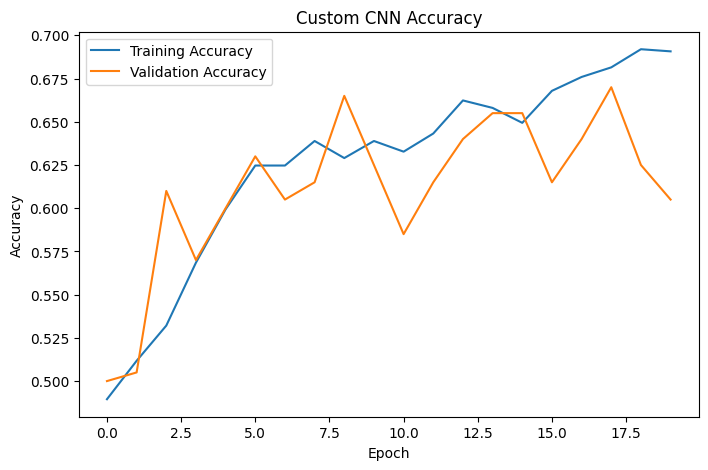

In [218]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN Accuracy")

plt.legend()

plt.savefig("custom_cnn_accuracy.png")

plt.show()

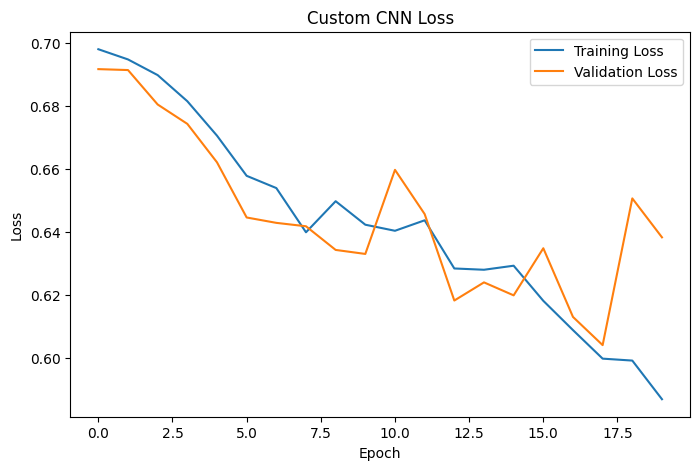

In [219]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN Loss")

plt.legend()

plt.savefig("custom_cnn_loss.png")

plt.show()

In [220]:
test_loss, test_accuracy = custom_cnn.evaluate(test_generator)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Loss : {test_loss:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.6850 - loss: 0.5844
Test Accuracy : 0.6850
Test Loss : 0.5844


In [221]:
predictions = custom_cnn.predict(test_generator)

predicted_classes = (predictions > 0.5).astype(int).flatten()

true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step


In [222]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

              precision    recall  f1-score   support

        safe       0.66      0.76      0.71       100
      unsafe       0.72      0.61      0.66       100

    accuracy                           0.69       200
   macro avg       0.69      0.69      0.68       200
weighted avg       0.69      0.69      0.68       200



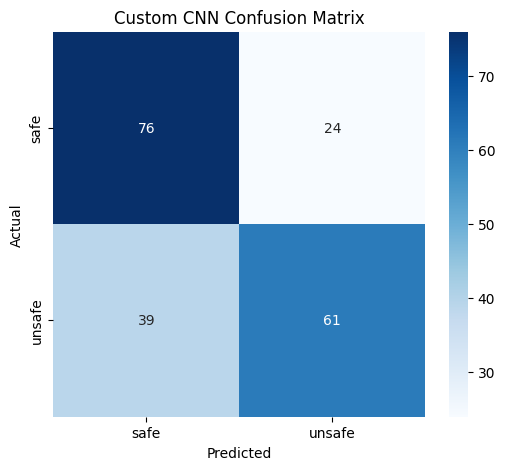

In [223]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Custom CNN Confusion Matrix")

plt.savefig("custom_cnn_confusion_matrix.png")

plt.show()

In [224]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

In [225]:
base_model = MobileNetV2(
    weights=None,
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [226]:
base_model = MobileNetV2(
    weights=None,   # ✅ CHANGE THIS
    include_top=False,
    input_shape=(224,224,3)
)

In [227]:
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

In [228]:
# true_classes will NOT match predictions

In [229]:
test_generator = test_generator
test_generator.reset()

In [230]:
shuffle=False

In [231]:
mobile_predictions = mobilenet_model.predict(test_generator)
mobile_predicted_classes = (mobile_predictions > 0.5).astype(int).flatten()

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 762ms/step


In [232]:
mobile_predicted_classes = (mobile_predictions.ravel() > 0.5).astype(int)

In [233]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [234]:
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
validation_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [235]:
mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [236]:
test_generator.reset()

test_loss_mobile, test_accuracy_mobile = mobilenet_model.evaluate(test_generator)

print(test_accuracy_mobile)

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 601ms/step - accuracy: 0.5000 - loss: 0.6931
0.5


In [237]:
cnn_accuracy = test_accuracy
mobile_accuracy = test_accuracy_mobile

In [238]:
#true_classes will NOT match predictions

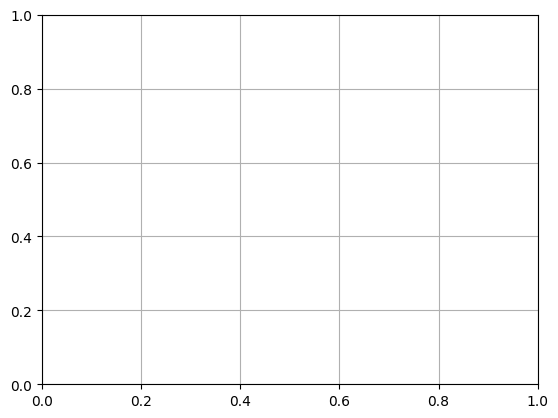

In [239]:
plt.grid(True)